# FABN Bond Portfolio Optimizer -- Gurobi  *(v2 -- Lending Facility + Cash Shielding + Bond Liquidation)*

---

## Pipeline Overview
0. **Run data pipeline** -- BigQuery, bond universe, FABN schedule, cash flows, durations, C-1 charges + Gurobi imports
1. **Data & Parameters** -- load inputs; build bond liquidation proceeds credited at FABN maturity quarter
2. **Gurobi Model** -- formulate and solve the LP
3. **Results** -- extract allocations and NEV breakdown
4. **Analytics** -- tables and charts

---

## Run Order

**Always run:** Date Selection -> Section 0 -> 1A -> 2 -> 3 -> 4

To change the optimization date, update `optimization_date` in the Date Selection cell and re-run all cells top-to-bottom.

**Optional overrides** (uncomment individual blocks before re-running Section 2):

| Section | Purpose |
|---|---|
| **1B -- Signal override** | Let market OAS z-scores influence bond selection |
| **1B -- Transaction cost override** | Penalize portfolio turnover via bid-ask spread proxy |
| **1B -- Solvency override** | Use confirmed regulatory capital figures from Athene |
| **1B -- Facility/shortfall override** | Adjust `r_lend` or `phi_sf` from their defaults |
| **1C -- Accrual + Valuation score** | Use coupon-based return instead of OAS spread proxy |
| **1C -- After-tax score** | Apply tax adjustments (requires 1C accrual block active) |
| **2E -- Issuer concentration** | Cap single-issuer exposure (active by default) |


---
## Section 0 -- Pipeline Run & Imports

In [1]:
# =============================================================================
# DATE SELECTION  --  change this date, then re-run all cells top-to-bottom
# =============================================================================
# Set to any business day for which spread data exists in BigQuery.
# Valid range: 2022-09-07 (day after FABN issue) through 2027-09-05 (day before maturity).

import pandas as pd   # imported here so the date is available before %run

optimization_date = pd.Timestamp("2025-01-15")   # <- CHANGE THIS DATE

# -- Validation ---------------------------------------------------------------
_FABN_ISSUE    = pd.Timestamp("2022-09-06")
_FABN_MATURITY = pd.Timestamp("2027-09-06")

assert optimization_date <= pd.Timestamp.today(), (
    f"Date {optimization_date.date()} is in the future -- no market data available."
)
assert optimization_date > _FABN_ISSUE, (
    f"Date {optimization_date.date()} must be after FABN issue ({_FABN_ISSUE.date()})."
)
assert optimization_date < _FABN_MATURITY, (
    f"Date {optimization_date.date()} is on or after FABN maturity ({_FABN_MATURITY.date()}). "
    f"No future FABN payments remain -- D_FABN would be undefined."
)

print(f"Optimization date selected : {optimization_date.date()}")
print("Re-run all sections below (0 -> 1A -> 2 -> 3 -> 4) to update the portfolio optimization.")

Optimization date selected : 2025-01-15
Re-run all sections below (0 -> 1A -> 2 -> 3 -> 4) to update the portfolio optimization.


In [2]:
# Runs the data pipeline -- loads bond universe, FABN schedule, cash flows,
# durations, C-1 charges, spreads, and all model parameters into `pipeline`.
%run FABN_Data_Pipeline.ipynb

import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt
# numpy and pandas are already imported by the pipeline

Connected: insurance-backed-securities
Optimization date  : 2025-01-15
FABN issue/maturity: 2022-09-06 → 2027-09-06
Budget H           : $500,000,000
r_FABN             : 3.205%
Universe size N = 303 bonds
Spread coverage : 301/303 bonds  (2 missing)
Spread range    : -1.6 – 153.7 bps
Cashflow rows loaded : 2,517
Date range           : 2025-01-16 → 2033-02-15
bond_cf shape : (850, 303)  (T=850 payment dates × N=303 bonds)
qtr_bond_cf shape : (33, 303)  (Q=33 quarters × N=303 bonds)
Quarter range     : 2025Q1 → 2033Q1
Treasury curve date used : 2025-01-15
0.083yr     4.40
0.250yr     4.35
0.500yr     4.26
1.000yr     4.19
2.000yr     4.27
3.000yr     4.34
5.000yr     4.45
7.000yr     4.55
10.000yr    4.66
20.000yr    4.95
30.000yr    4.88

Duration computed from cashflows : 303
Duration from BBG fallback       : 0
Duration range                   : 1.16 – 6.40 yrs
Mean bond yield used             : 4.948%
theta range : 0.00158 – 0.02168
Mean C1     : 0.00911  (0.911%)
h_curr (equal-weig

,Metric,Value,Notes
0,Universe size (N),303,
1,Payment dates (T),850,
2,Quarterly periods (Q),33,
3,Spread mean (bps),59.4,
4,Duration mean (yrs),2.97,
5,C1 charge mean (%),0.911,
6,FABN D target (yrs),2.489641,
7,Budget H ($M),500.0,



pipeline dict ready.


---
## Section 1 -- Data & Parameters

In [3]:
# =============================================================================
# 1A. UNPACK PIPELINE  --  always run
# =============================================================================

N            = pipeline["N"]
T            = pipeline["T"]
Q            = pipeline["Q"]
CUSIPS       = pipeline["CUSIPS"]

spread       = pipeline["spread"]       # Spread_i = y_i - r_FABN  (decimal)
durs         = pipeline["durs"]         # D_i : modified duration (years)
theta        = pipeline["theta"]        # theta_i : C-1 RBC charge factor
h_curr       = pipeline["h_curr"]       # h_curr_i : current allocation ($)

bond_cf      = pipeline["bond_cf"]      # asset cash flows  (T x N)
qtr_bond_cf  = pipeline["qtr_bond_cf"]  # quarterly view    (Q x N)
qtr_fabn_cf  = pipeline["qtr_fabn_cf"]  # FABN liability cash flows (Q,)
qtr_idx      = pipeline["qtr_idx"]

H            = pipeline["H"]            # total budget ($)
r_FABN       = pipeline["r_FABN"]       # funding rate r^FABN (annual)
D_FABN       = pipeline["D_FABN"]       # liability modified duration (yrs)
RBC_bar      = pipeline["RBC_bar"]      # target RBC ratio for this FABN block
dt           = pipeline["dt"]           # time scaling factor (annualized)

gamma_w      = pipeline["gamma_w"]      # gamma  : weight on capital cost (C1 + C3)
beta_w       = pipeline["beta_w"]       # beta   : weight on market signal (0 by default)
alpha_w      = pipeline["alpha_w"]      # alpha  : C3 scaling for duration mismatch
eps_D        = pipeline["eps_D"]        # epsilon_D : duration band tolerance (yrs)

signal       = pipeline["signal"]       # Signal_i  (N,) -- zeros by default
tau          = pipeline["tau"]          # tau_i     (N,) -- zeros by default
score        = pipeline["score"]        # score_i = spread_i + beta_w * signal_i

print(f"Pipeline loaded: N={N}, T={T}, Q={Q}")
print(f"Optimization date: {optimization_date.date()}")

Pipeline loaded: N=303, T=850, Q=33
Optimization date: 2025-01-15


In [4]:
# =============================================================================
# 1B. INPUT OVERRIDES  --  run this cell only when you uncomment a block below
# =============================================================================
# Each block is independent. Note: if both the signal override (1B) and a score override (1C) are active, the 1C override takes precedence and replaces the score set here.
# After uncommenting, re-run this cell and then re-run Section 2.

# ---------------------------------------------------------------------------
# UNCOMMENT IF: you want market OAS signals to influence which bonds are selected.
# ---------------------------------------------------------------------------
# Computes a sector-level OAS z-score from available data.
# Bonds trading wide vs. sector peers receive a positive signal (relatively cheap).
# Sets beta_w = 0.10 so the signal term in the objective has weight.
#
# fixed_df   = pipeline["fixed"]
# sector_map = fixed_df.set_index("CUSIP")["sector"]
# spread_s   = pd.Series(spread, index=CUSIPS)
# signal     = spread_s.groupby(sector_map).transform(
#                  lambda x: (x - x.mean()) / (x.std() + 1e-8)
#              ).values
# beta_w     = 0.10
# score      = spread + beta_w * signal

# ---------------------------------------------------------------------------
# UNCOMMENT IF: you want to penalize portfolio turnover (transaction costs).
# ---------------------------------------------------------------------------
# Assigns 5 bps to investment-grade bonds and 20 bps to high-yield bonds
# as a bid-ask spread proxy. Replace with per-bond Bloomberg data when available.
#
# theta <= 0.02 is used as a rough investment-grade proxy (lower C-1 charges correspond to higher credit quality)
# tau = np.where(theta <= 0.02, 0.0005, 0.0020)

# ---------------------------------------------------------------------------
# UNCOMMENT IF: you want to override the target RBC ratio confirmed by Athene.
# ---------------------------------------------------------------------------
# RBC_bar range: 1.2 (lenient) to 2.5 (conservative). Confirm with Athene before changing.
#
# RBC_bar = 2.0    # target RBC ratio for this FABN block

# ---------------------------------------------------------------------------
# UNCOMMENT IF: you want to override the lending facility or shortfall rates.
# ---------------------------------------------------------------------------
# Defaults (set at the top of Section 2):
#   r_save   = r_FABN  (~3.205%)  -- rate earned on surplus in the lending facility
#   r_borrow = 0.05    (  5.00%)  -- rate paid on any unmet quarterly CF shortfall
#   phi_sf   = 0.01    (  1.00%)  -- max PV(shortfall) / PV(liability) hard cap
#
# r_save   = 0.04    # e.g. use a money-market rate instead of r_FABN
# r_borrow = 0.06    # e.g. tighten shortfall cost assumption
# phi_sf   = 0.005   # tighten PV shortfall cap to 0.5% of PV(liability)

---
### Section 1C -- Score Override *(uncomment and run before Section 2 if activating)*

In [5]:
# =============================================================================
# 1C. SCORE / RETURN OVERRIDES  --  run this cell only when you uncomment a block below
# =============================================================================
# These blocks replace the `score` variable used in the optimizer objective function.
# Run this cell BEFORE Section 2; re-run Section 2 after changing score.

# ---------------------------------------------------------------------------
# UNCOMMENT IF: you want coupon-based return instead of the OAS spread proxy.
# ---------------------------------------------------------------------------
# Return_i = Accrual_i + Valuation_i
#   accrual[i]   = annual coupon rate of bond i (decimal)
#   valuation[i] = expected price change -- set to 0 until a rate forecast is available
#   score[i]     = accrual[i] + valuation[i] - r_FABN
#
# fixed_df   = pipeline["fixed"]
# coupon_map = fixed_df.set_index("CUSIP")["coupon"] / 100.0
# accrual    = np.array([coupon_map[c] for c in CUSIPS])
# valuation  = np.zeros(N)
# score      = accrual + valuation - r_FABN

# ---------------------------------------------------------------------------
# UNCOMMENT IF: the accrual block above is active and you want after-tax returns.
# ---------------------------------------------------------------------------
# Return_i^AT = (1 - pi_c) * Accrual_i + (1 - pi_g) * Valuation_i
# Requires the accrual block above to be uncommented first.
#
# pi_c  = 0.21    # ordinary income tax rate
# pi_g  = 0.15    # capital gains tax rate
# score = (1 - pi_c) * accrual + (1 - pi_g) * valuation - r_FABN
# Note: r_FABN is not tax-adjusted here; treat the funding cost as a pre-tax benchmark rate

---
## Section 2 -- Gurobi Optimization Model

In [6]:
# =============================================================================
# 2. GUROBI OPTIMIZATION MODEL  --  always run
# =============================================================================

model = gp.Model("FABN_NEV_Optimizer")
model.Params.LogToConsole = 1   # set to 0 to suppress solver output

# -- Rates and time step  (override in Section 1B before running) -------------
r_save   = r_FABN   # annualized rate earned on facility surplus (default = r_FABN ~3.205%)
r_borrow = 0.05     # annualized rate paid on any unmet CF shortfall
phi_sf   = 0.01     # PV shortfall hard cap -- max PV(shortfall) / PV(liability)
dt_q     = 0.25     # quarter length in years

# ---------------------------------------------------------------------------
# 2A. DECISION VARIABLES
# ---------------------------------------------------------------------------

h = model.addVars(N, lb=0.0, name="h")

# ---------------------------------------------------------------------------
# 2B. AUXILIARY VARIABLES
# ---------------------------------------------------------------------------

# Duration gap decomposition: d_pos - d_neg = sum(D_i * h_i) - D_FABN * H
d_pos = model.addVar(lb=0.0, name="d_pos")
d_neg = model.addVar(lb=0.0, name="d_neg")

# Transaction cost decomposition: tc_plus_i - tc_minus_i = h_i - h_curr_i
tc_plus  = model.addVars(N, lb=0.0, name="tc_plus")
tc_minus = model.addVars(N, lb=0.0, name="tc_minus")

# Lending facility: B[q] = accumulated surplus balance; s_net[q] = residual shortfall
B     = model.addVars(Q, lb=0.0, name="B")
s_net = model.addVars(Q, lb=0.0, name="s_net")

# ---------------------------------------------------------------------------
# 2C. OBJECTIVE FUNCTION
# ---------------------------------------------------------------------------

spread_income = gp.quicksum(score[i] * durs[i] * h[i] for i in range(N))  # duration-weighted: total PV of spread income over bond life
C1            = gp.quicksum(theta[i] * h[i] for i in range(N))
C3            = alpha_w * (d_pos + d_neg)
# RBC capital cost: insurer holds RBC_bar x C1 in capital; WACC on that capital, PV-scaled by D_FABN
capital_cost  = gamma_w * RBC_bar * C1 * D_FABN
txn_cost      = gp.quicksum(tau[i] * (tc_plus[i] + tc_minus[i]) for i in range(N))

# Lending facility interest is included in the LP objective.
# Without the phi_sf cap (Section 2D), the LP would maximize savings income arbitrarily; the hard cap prevents this.
sav_obj = r_save   * dt_q * gp.quicksum(B[q]     for q in range(Q - 1))  # Q-1: interest earned on balance entering each period; final quarter has no subsequent period
bor_obj = r_borrow * dt_q * gp.quicksum(s_net[q] for q in range(Q))
NEV = spread_income - capital_cost - txn_cost + sav_obj - bor_obj
model.setObjective(NEV, GRB.MAXIMIZE)

# ---------------------------------------------------------------------------
# 2D. CORE CONSTRAINTS  --  always active
# ---------------------------------------------------------------------------

# Budget: total allocated capital equals H
model.addConstr(
    gp.quicksum(h[i] for i in range(N)) == H,
    name="budget"
)

# RBC is enforced implicitly: the optimizer pays gamma_w * RBC_bar * theta_i * D_FABN
# per dollar in bond i -- equivalent to holding required capital at WACC cost.

# Duration alignment: portfolio average duration must stay within eps_D of D_FABN
model.addConstr(
    gp.quicksum(durs[i] * h[i] for i in range(N)) - D_FABN * H == d_pos - d_neg,
    name="dur_gap_decomp"
)
model.addConstr(d_pos <= eps_D * H, name="dur_upper")
model.addConstr(d_neg <= eps_D * H, name="dur_lower")

# Transaction cost decomposition
for i in range(N):
    model.addConstr(
        h[i] - h_curr[i] == tc_plus[i] - tc_minus[i],
        name=f"tc_decomp_{i}"
    )

# -- Lending Facility + Cash Shielding ----------------------------------------

t_quarters = [dt_q * (q + 1) for q in range(Q)]
df_q       = [(1.0 + r_FABN) ** (-t) for t in t_quarters]

# -- Bond liquidation at FABN maturity ----------------------------------------
# Bonds whose cash flows extend past the FABN end date are excluded via upper bound 0.
# Their hold-to-maturity proceeds would arrive after the liability is settled,
# so they cannot be used to meet FABN payments.
fabn_last_q = max(q for q in range(Q) if float(qtr_fabn_cf[q]) > 0)

post_fabn_mask = np.any(qtr_bond_cf[fabn_last_q + 1:] > 1e-6, axis=0)  # shape (N,)
_n_excluded = int(post_fabn_mask.sum())
for i in range(N):
    if post_fabn_mask[i]:
        h[i].ub = 0.0
print(f"Hold-to-maturity: {_n_excluded}/{N} bonds excluded "
      f"(cash flows extend past {qtr_idx[fabn_last_q]})")

# Lending facility balance dynamics -- surplus earns r_save each quarter
for q in range(Q):
    CF_A_q = gp.quicksum(qtr_bond_cf[q, i] * h[i] for i in range(N))
    CF_L_q = float(qtr_fabn_cf[q])
    if q == 0:
        model.addConstr(B[q] - s_net[q] == CF_A_q - CF_L_q,
                        name=f"facility_balance_{q}")
    else:
        model.addConstr(B[q] - s_net[q] == (1.0 + r_save * dt_q) * B[q - 1] + CF_A_q - CF_L_q,
                        name=f"facility_balance_{q}")

# PV shortfall hard cap -- ensures total discounted shortfall stays within phi_sf of PV(liability)
PV_liability = float(sum(float(qtr_fabn_cf[q]) * df_q[q] for q in range(Q)))
model.addConstr(
    gp.quicksum(df_q[q] * s_net[q] for q in range(Q)) <= phi_sf * PV_liability,
    name="pv_shortfall_limit"
)
print(f"r_save   (surplus earns, in dynamics)  : {r_save   * 100:.3f}%  per year")
print(f"r_borrow (shortfall cost, in obj)      : {r_borrow * 100:.2f}%  per year")
print(f"PV(FABN liability)                     = ${PV_liability:>14,.2f}")

# ---------------------------------------------------------------------------
# 2E. ISSUER CONCENTRATION CONSTRAINT  --  active by default (5% cap per issuer)
# ---------------------------------------------------------------------------

delta = 0.05   # max 5% of total budget per issuer
issuer_groups = {}
for idx, cusip in enumerate(CUSIPS):
    issuer_groups.setdefault(cusip[:6], []).append(idx)
for issuer, bond_indices in issuer_groups.items():
    model.addConstr(
        gp.quicksum(h[i] for i in bond_indices) <= delta * H,
        name=f"concentration_{issuer}"
    )

# ---------------------------------------------------------------------------
# 2F. SOLVE
# ---------------------------------------------------------------------------

model.optimize()

Restricted license - for non-production use only - expires 2027-11-29
Set parameter LogToConsole to value 1
Hold-to-maturity: 175/303 bonds excluded (cash flows extend past 2027Q3)
r_save   (surplus earns, in dynamics)  : 3.205%  per year
r_borrow (shortfall cost, in obj)      : 5.00%  per year
PV(FABN liability)                     = $504,320,737.28
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[rosetta2] - Darwin 24.6.0 24G90)

CPU model: Apple M4 Pro
Thread count: 12 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 566 rows, 977 columns and 4167 nonzeros (Max)
Model fingerprint: 0xa77a73e1
Model has 368 linear objective coefficients
Coefficient statistics:
  Matrix range     [5e-03, 6e+00]
  Objective range  [8e-05, 7e-02]
  Bounds range     [0e+00, 0e+00]
  RHS range        [2e+06, 1e+09]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.

Presolve removed 541 rows and 835 columns


---
## Section 3 -- Results

In [7]:
# =============================================================================
# 3. RESULTS EXTRACTION  --  always run
# =============================================================================

if model.Status == GRB.OPTIMAL:

    h_opt = np.array([h[i].X for i in range(N)])

    spread_income_val = float(sum(score[i] * durs[i] * h_opt[i] for i in range(N)))
    C1_val            = float(sum(theta[i] * h_opt[i] for i in range(N)))
    C3_val            = alpha_w * (d_pos.X + d_neg.X)
    required_capital  = RBC_bar * (C1_val + C3_val)   # capital insurer must hold ($)
    capital_cost_val  = gamma_w * required_capital * D_FABN
    txn_cost_val      = float(sum(tau[i] * (tc_plus[i].X + tc_minus[i].X) for i in range(N)))

    # Extract facility solution as plain floats -- reused in Sections 3B and 4
    B_vals     = [B[q].X     for q in range(Q)]
    s_net_vals = [s_net[q].X for q in range(Q)]

    # Breakdown for reporting (savings/borrowing are included in the LP objective value)
    savings_income_val = r_save   * dt_q * float(sum(B_vals[q]     for q in range(Q - 1)))
    borrowing_cost_val = r_borrow * dt_q * float(sum(s_net_vals[q] for q in range(Q)))

    nev_val = model.ObjVal

    D_avg   = float(sum(durs[i] * h_opt[i] for i in range(N))) / H
    RBC_val = required_capital / C1_val   # = RBC_bar by construction (when C3 = 0)

    print(f"{'='*55}")
    print(f"  OPTIMAL NEV (reported)   : ${nev_val:>12,.2f}")
    print(f"  (1) Spread income        : ${spread_income_val:>12,.2f}")
    print(f"  (2) Savings income       : ${savings_income_val:>12,.2f}")
    print(f"  (3) Capital cost (C1+C3) : ${capital_cost_val:>12,.2f}")
    print(f"      - C1 (credit risk)   : ${C1_val:>12,.2f}")
    print(f"      - C3 (duration ALM)  : ${C3_val:>12,.2f}")
    print(f"  (4) Transaction costs    : ${txn_cost_val:>12,.2f}")
    print(f"  (5) Borrowing cost       : ${borrowing_cost_val:>12,.2f}")
    print(f"{'='*55}")
    print(f"  Portfolio D_avg          :  {D_avg:.4f} yrs  (target {D_FABN} +/- {eps_D})")
    print(f"  RBC ratio                :  {RBC_val:.2f}x  (min {RBC_bar:.1f}x)")
    print(f"{'='*55}")

    # Constraint status table
    constraints_df = pd.DataFrame({
        "Constraint"  : [
            "Budget  (Sum h_i = H)",
            "RBC ratio  (implicitly via capital cost)",
            "Duration  (|D_avg - D_FABN| <= eps_D)",
        ],
        "Value"       : [h_opt.sum(), RBC_val, abs(D_avg - D_FABN)],
        "Bound"       : [H, RBC_bar, eps_D],
        "Pass / Fail" : [
            "PASS" if abs(h_opt.sum() - H) < 1.0  else "FAIL",
            "PASS" if RBC_val >= RBC_bar            else "FAIL",
            "PASS" if abs(D_avg - D_FABN) <= eps_D else "FAIL",
        ],
    })
    display(constraints_df)

    CF_A_vals = [sum(qtr_bond_cf[q, i] * h_opt[i] for i in range(N)) for q in range(Q)]
    cf_df = pd.DataFrame({
        "Period"              : qtr_idx,
        "FABN CF ($)"         : qtr_fabn_cf,
        "Asset CF ($)"        : CF_A_vals,
        "Surplus ($)"         : [a - l for a, l in zip(CF_A_vals, qtr_fabn_cf)],
        "Shortfall net ($)"   : s_net_vals,
        "Facility bal ($)"    : B_vals,
    })
    display(cf_df)

elif model.Status == GRB.INFEASIBLE:
    print("Model is INFEASIBLE. Computing IIS to identify conflicting constraints...")
    model.computeIIS()
    model.write("infeasible.ilp")
    print("IIS written to infeasible.ilp")

else:
    print(f"Solver status code: {model.Status} -- no optimal solution found.")

  OPTIMAL NEV (reported)   : $14,554,820.29
  (1) Spread income        : $7,770,588.01
  (2) Savings income       : $9,821,990.58
  (3) Capital cost (C1+C3) : $2,974,219.06
      - C1 (credit risk)   : $5,309,500.00
      - C3 (duration ALM)  : $        0.00
  (4) Transaction costs    : $        0.00
  (5) Borrowing cost       : $   63,539.24
  Portfolio D_avg          :  2.1896 yrs  (target 2.4896414655541794 +/- 0.3)
  RBC ratio                :  1.50x  (min 1.5x)


,Constraint,Value,Bound,Pass / Fail
0,Budget (Sum h_i = H),500000000.0,500000000.0,PASS
1,RBC ratio (implicitly via capital cost),1.5,1.5,PASS
2,Duration (|D_avg - D_FABN| <= eps_D),0.3,0.3,FAIL


,Period,FABN CF ($),Asset CF ($),Surplus ($),Shortfall net ($),Facility bal ($)
0,2025Q1,8012500.0,1.005006e+07,2.037559e+06,5.083139e+06,7.120698e+06
1,2025Q2,0.0,8.062500e+05,8.062500e+05,0.000000e+00,7.984003e+06
2,2025Q3,8012500.0,1.187643e+07,3.863934e+06,0.000000e+00,1.191191e+07
3,2025Q4,0.0,8.062500e+05,8.062500e+05,0.000000e+00,1.281360e+07
4,2026Q1,8012500.0,1.187643e+07,3.863934e+06,0.000000e+00,1.678020e+07
5,2026Q2,0.0,8.062500e+05,8.062500e+05,0.000000e+00,1.772091e+07
6,2026Q3,8012500.0,1.187643e+07,3.863934e+06,0.000000e+00,2.172683e+07
7,2026Q4,0.0,8.062500e+05,8.062500e+05,0.000000e+00,2.270717e+07
8,2027Q1,8012500.0,1.638719e+08,1.558594e+08,0.000000e+00,1.787485e+08
9,2027Q2,0.0,2.580625e+07,2.580625e+07,0.000000e+00,2.059870e+08


### Section 3B -- Expanded Quarterly Cash Flow Table

In [8]:
# =============================================================================
# 3B. EXPANDED QUARTERLY CASH FLOW TABLE
# =============================================================================
# Shows FABN payments, asset payments, interest earned on the facility surplus,
# and the running ending balance through all quarters.
# After FABN maturity, facility mechanics stop. Post-maturity rows are zero because bonds with cash flows past FABN maturity were excluded from the portfolio.
# =============================================================================

if model.Status != GRB.OPTIMAL:
    print(f"Section 3B skipped -- model status = {model.Status} (not optimal). "
          "Run Sections 2 and 3 successfully first.")
else:
    # Natural bond CFs for post-FABN quarters (hold to maturity, no liquidation)
    natural_cf_vals = [
        sum(qtr_bond_cf[q, i] * h_opt[i] for i in range(N))
        for q in range(Q)
    ]

    # Use optimizer solution through fabn_last_q; natural CFs after
    asset_payment = [
        CF_A_vals[q] if q <= fabn_last_q else natural_cf_vals[q]
        for q in range(Q)
    ]

    # Facility mechanics only apply while the FABN is live
    int_income_on_surplus = [
        B_vals[q - 1] * r_save * dt_q if (q > 0 and q <= fabn_last_q) else 0.0
        for q in range(Q)
    ]
    int_cost_on_shortfall = [
        s_net_vals[q] * r_borrow * dt_q if q <= fabn_last_q else 0.0
        for q in range(Q)
    ]

    period_net = [asset_payment[q] - float(qtr_fabn_cf[q]) for q in range(Q)]

    ending_balance = []
    _bal = 0.0
    for q in range(Q):
        _bal += period_net[q] + int_income_on_surplus[q] - int_cost_on_shortfall[q]
        ending_balance.append(_bal)

    rows = []
    for q in range(Q):
        rows.append({
            "Period"                    : str(qtr_idx[q]),
            "FABN Payment ($)"          : float(qtr_fabn_cf[q]),
            "Asset Payment ($)"         : asset_payment[q],
            "Surplus / (Shortfall) ($)" : period_net[q],
            "Interest on Surplus ($)"   : int_income_on_surplus[q],
            "Interest on Shortfall ($)" : int_cost_on_shortfall[q],
            "Ending Balance ($)"        : ending_balance[q],
        })

    expanded_df = pd.DataFrame(rows)

    dollar_cols = [c for c in expanded_df.columns if c != "Period"]

    def _fmt(df):
        out = df.copy()
        for col in dollar_cols:
            out[col] = out[col].apply(
                lambda v: f"(${abs(v):>16,.2f})" if v < 0 else f" ${v:>16,.2f} "
            )
        return out

    active = (
        (expanded_df["FABN Payment ($)"]          > 0) |
        (expanded_df["Asset Payment ($)"]         > 0) |
        (expanded_df["Interest on Shortfall ($)"] > 1e-6)
    )

    print("=" * 80)
    print("ACTIVE QUARTERS  (zero-CF quarters hidden -- see full table below)")
    print("=" * 80)
    display(_fmt(expanded_df[active].reset_index(drop=True)))

    print("\n" + "=" * 80)
    print("FULL TABLE -- all quarters")
    print("=" * 80)
    display(_fmt(expanded_df.reset_index(drop=True)))

ACTIVE QUARTERS  (zero-CF quarters hidden -- see full table below)


,Period,FABN Payment ($),Asset Payment ($),Surplus / (Shortfall) ($),Interest on Surplus ($),Interest on Shortfall ($),Ending Balance ($)
0,2025Q1,"$ 8,012,500.00","$ 10,050,058.71","$ 2,037,558.71",$ 0.00,"$ 63,539.24","$ 1,974,019.47"
1,2025Q2,$ 0.00,"$ 806,250.00","$ 806,250.00","$ 57,054.59",$ 0.00,"$ 2,837,324.06"
2,2025Q3,"$ 8,012,500.00","$ 11,876,433.71","$ 3,863,933.71","$ 63,971.82",$ 0.00,"$ 6,765,229.59"
3,2025Q4,$ 0.00,"$ 806,250.00","$ 806,250.00","$ 95,444.16",$ 0.00,"$ 7,666,923.76"
4,2026Q1,"$ 8,012,500.00","$ 11,876,433.71","$ 3,863,933.71","$ 102,668.99",$ 0.00,"$ 11,633,526.45"
5,2026Q2,$ 0.00,"$ 806,250.00","$ 806,250.00","$ 134,451.39",$ 0.00,"$ 12,574,227.85"
6,2026Q3,"$ 8,012,500.00","$ 11,876,433.71","$ 3,863,933.71","$ 141,988.76",$ 0.00,"$ 16,580,150.32"
7,2026Q4,$ 0.00,"$ 806,250.00","$ 806,250.00","$ 174,086.22",$ 0.00,"$ 17,560,486.53"
8,2027Q1,"$ 8,012,500.00","$ 163,871,908.57","$ 155,859,408.57","$ 181,941.16",$ 0.00,"$ 173,601,836.27"
9,2027Q2,$ 0.00,"$ 25,806,250.00","$ 25,806,250.00","$ 1,432,222.47",$ 0.00,"$ 200,840,308.74"



FULL TABLE -- all quarters


,Period,FABN Payment ($),Asset Payment ($),Surplus / (Shortfall) ($),Interest on Surplus ($),Interest on Shortfall ($),Ending Balance ($)
0,2025Q1,"$ 8,012,500.00","$ 10,050,058.71","$ 2,037,558.71",$ 0.00,"$ 63,539.24","$ 1,974,019.47"
1,2025Q2,$ 0.00,"$ 806,250.00","$ 806,250.00","$ 57,054.59",$ 0.00,"$ 2,837,324.06"
2,2025Q3,"$ 8,012,500.00","$ 11,876,433.71","$ 3,863,933.71","$ 63,971.82",$ 0.00,"$ 6,765,229.59"
3,2025Q4,$ 0.00,"$ 806,250.00","$ 806,250.00","$ 95,444.16",$ 0.00,"$ 7,666,923.76"
4,2026Q1,"$ 8,012,500.00","$ 11,876,433.71","$ 3,863,933.71","$ 102,668.99",$ 0.00,"$ 11,633,526.45"
5,2026Q2,$ 0.00,"$ 806,250.00","$ 806,250.00","$ 134,451.39",$ 0.00,"$ 12,574,227.85"
6,2026Q3,"$ 8,012,500.00","$ 11,876,433.71","$ 3,863,933.71","$ 141,988.76",$ 0.00,"$ 16,580,150.32"
7,2026Q4,$ 0.00,"$ 806,250.00","$ 806,250.00","$ 174,086.22",$ 0.00,"$ 17,560,486.53"
8,2027Q1,"$ 8,012,500.00","$ 163,871,908.57","$ 155,859,408.57","$ 181,941.16",$ 0.00,"$ 173,601,836.27"
9,2027Q2,$ 0.00,"$ 25,806,250.00","$ 25,806,250.00","$ 1,432,222.47",$ 0.00,"$ 200,840,308.74"


---
## Section 4 -- Analytics

,Component,Value ($)
0,Spread Income,7.770588e+06
1,Savings Income (Facility Surplus),9.821991e+06
2,Capital Cost (C1 + C3),-2.974219e+06
3,- C1 Credit Risk,-5.309500e+06
4,- C3 Duration Mismatch,-0.000000e+00
5,Transaction Costs,-0.000000e+00
6,Borrowing Cost,-6.353924e+04
7,NET ECONOMIC VALUE,1.455482e+07


,Metric,Value
0,Bonds selected (h > $1),21
1,Weighted avg spread (bps),71.23
2,Weighted avg duration (yrs),2.1896
3,Weighted avg C-1 charge (%),1.062
4,Weighted avg score (bps),71.23
5,Total C-1 capital charge ($),"$5,309,500"
6,Duration gap (D_avg - D_FABN) (yrs),-0.3000
7,RBC ratio (x),1.50x


Non-zero allocations: 21 / 303 bonds


,CUSIP,Sector,Rating (S&P),h_opt ($),h_curr ($),Delta ($),Spread (bps),Duration (yr),Score (bps),C1 charge ($)
0,40428HA44,Financials,A,2.500000e+07,1.650165e+06,2.334983e+07,40.255769,1.916113,40.255769,204000.000000
1,166756AZ9,Energy,AA-,2.500000e+07,1.650165e+06,2.334983e+07,68.378837,1.925926,68.378837,130750.000000
2,AM6439740,Financials,BBB+,2.500000e+07,1.650165e+06,2.334983e+07,93.882165,1.936558,93.882165,315250.000000
3,686330AQ4,Financials,BBB+,2.500000e+07,1.650165e+06,2.334983e+07,46.141723,2.369140,46.141723,315250.000000
4,46115HBB2,Financials,BBB+,2.500000e+07,1.650165e+06,2.334983e+07,96.176367,2.276803,96.176367,315250.000000
5,880451AS8,Energy,BBB,2.500000e+07,1.650165e+06,2.334983e+07,68.638022,1.907067,68.638022,380750.000000
6,AO8886308,Financials,BBB,2.500000e+07,1.650165e+06,2.334983e+07,133.010839,2.347112,133.010839,380750.000000
7,472319AE2,Financials,BBB,2.500000e+07,1.650165e+06,2.334983e+07,60.954966,2.139931,60.954966,380750.000000
8,61238QAA6,Materials,BBB,2.500000e+07,1.650165e+06,2.334983e+07,107.082802,1.879802,107.082802,380750.000000
9,37045XEX0,Consumer Discretionary,BBB,2.500000e+07,1.650165e+06,2.334983e+07,82.766379,2.252451,82.766379,380750.000000


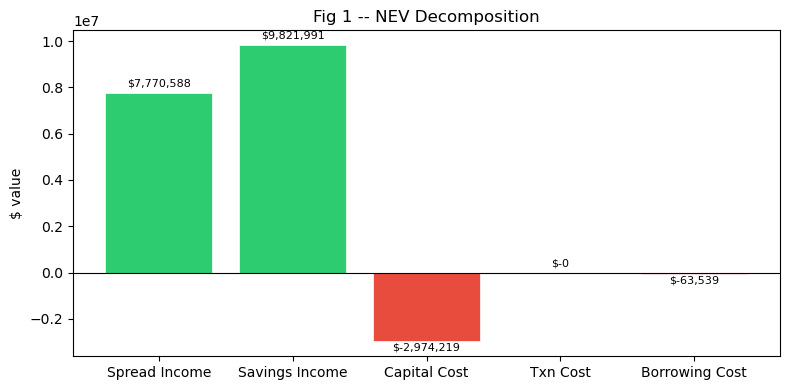

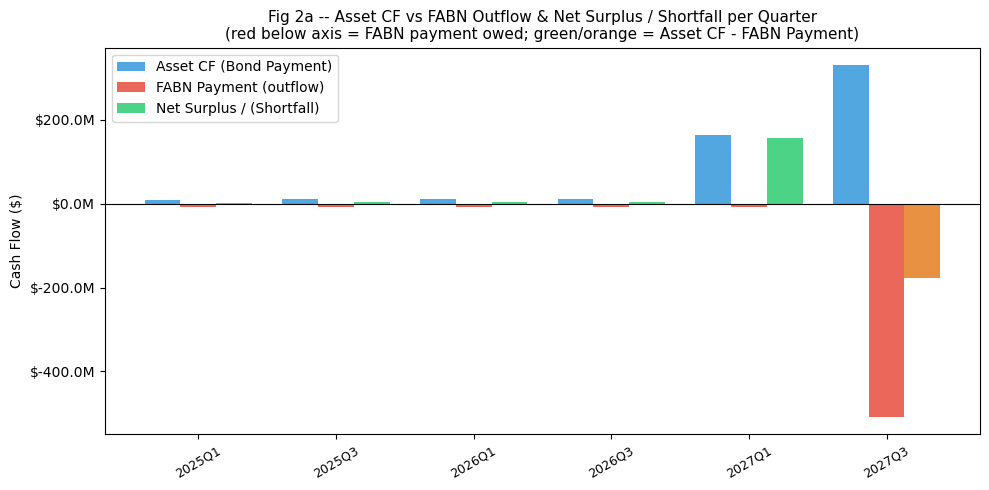

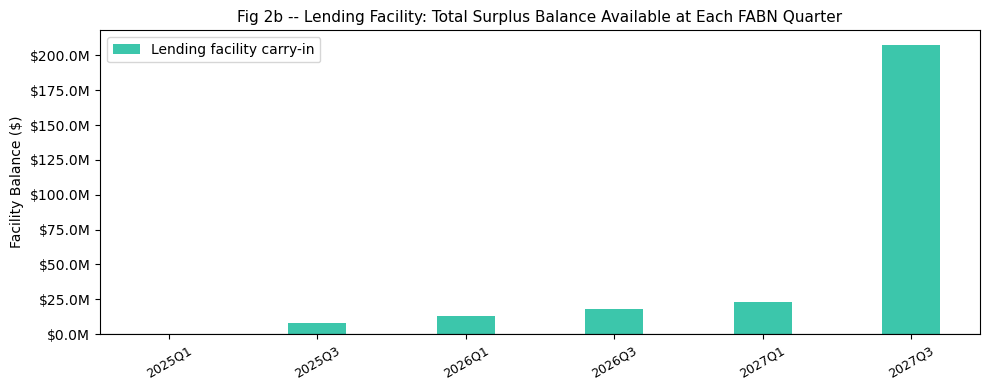

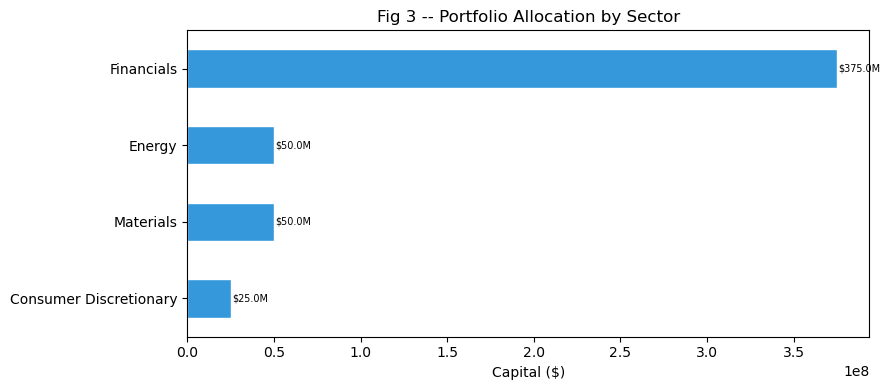

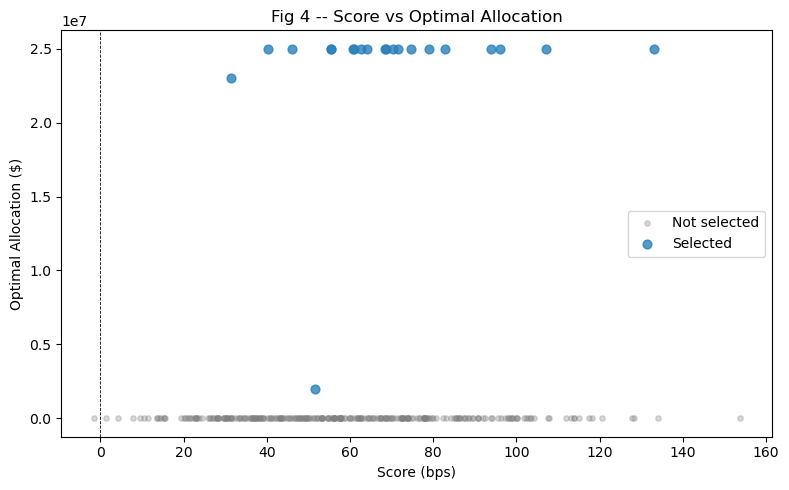

In [9]:
# =============================================================================
# 4. ANALYTICS  --  always run
# =============================================================================

# ---------------------------------------------------------------------------
# 4A. NEV SUMMARY TABLE
# ---------------------------------------------------------------------------
nev_summary = pd.DataFrame({
    "Component"  : [
        "Spread Income",
        "Savings Income (Facility Surplus)",
        "Capital Cost  (C1 + C3)",
        "  - C1 Credit Risk",
        "  - C3 Duration Mismatch",
        "Transaction Costs",
        "Borrowing Cost",
        "NET ECONOMIC VALUE",
    ],
    "Value ($)"  : [
        spread_income_val,
        savings_income_val,
        -capital_cost_val,
        -C1_val,
        -C3_val,
        -txn_cost_val,
        -borrowing_cost_val,
        nev_val,
    ],
})
display(nev_summary)

# ---------------------------------------------------------------------------
# 4B. PORTFOLIO ANALYTICS  (weighted averages over allocated bonds)
# ---------------------------------------------------------------------------
fixed_df  = pipeline["fixed"].set_index("CUSIP")
selected  = h_opt > 1.0
w         = h_opt[selected] / h_opt[selected].sum()

analytics = pd.DataFrame({
    "Metric": [
        "Bonds selected  (h > $1)",
        "Weighted avg spread  (bps)",
        "Weighted avg duration  (yrs)",
        "Weighted avg C-1 charge  (%)",
        "Weighted avg score  (bps)",
        "Total C-1 capital charge  ($)",
        "Duration gap  (D_avg - D_FABN)  (yrs)",
        "RBC ratio  (x)",
    ],
    "Value": [
        int(selected.sum()),
        f"{(spread[selected] * w).sum() * 1e4:.2f}",
        f"{(durs[selected] * w).sum():.4f}",
        f"{(theta[selected] * w).sum() * 100:.3f}",
        f"{(score[selected] * w).sum() * 1e4:.2f}",
        f"${(theta * h_opt).sum():,.0f}",
        f"{D_avg - D_FABN:+.4f}",
        f"{RBC_val:.2f}x",
    ],
})
display(analytics)

# ---------------------------------------------------------------------------
# 4C. ALLOCATION TABLE  (non-zero bonds only, sorted by allocation descending)
# ---------------------------------------------------------------------------
alloc_df = pd.DataFrame({
    "CUSIP"        : CUSIPS,
    "Sector"       : [str(fixed_df.loc[c, "sector"]) for c in CUSIPS],
    "Rating (S&P)" : [str(fixed_df.loc[c, "rating_sp"]).strip() for c in CUSIPS],
    "h_opt ($)"    : h_opt,
    "h_curr ($)"   : h_curr,
    "Delta ($)"    : h_opt - h_curr,
    "Spread (bps)" : spread * 1e4,
    "Duration (yr)": durs,
    "Score (bps)"  : score * 1e4,
    "C1 charge ($)": theta * h_opt,
})
alloc_nonzero = (
    alloc_df[alloc_df["h_opt ($)"] > 1.0]
    .sort_values("h_opt ($)", ascending=False)
    .reset_index(drop=True)
)
print(f"Non-zero allocations: {len(alloc_nonzero)} / {N} bonds")
display(alloc_nonzero)

# ---------------------------------------------------------------------------
# 4D. CHARTS
# ---------------------------------------------------------------------------

# -- Fig 1: NEV Decomposition --------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4))
components = [spread_income_val, savings_income_val, -capital_cost_val,
              -txn_cost_val, -borrowing_cost_val]
labels     = ["Spread Income", "Savings Income", "Capital Cost",
              "Txn Cost", "Borrowing Cost"]
colors     = ["#2ecc71" if v >= 0 else "#e74c3c" for v in components]
bars = ax.bar(labels, components, color=colors, edgecolor="white", linewidth=0.5)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Fig 1 -- NEV Decomposition")
ax.set_ylabel("$ value")
for bar, val in zip(bars, components):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + (max(components) * 0.02 if val >= 0 else min(components) * 0.02),
            f"${val:,.0f}", ha="center", va="bottom" if val >= 0 else "top", fontsize=8)
plt.tight_layout()
plt.show()

# -- Shared data for Fig 2a and Fig 2b -----------------------------------------
fabn_pay_idx   = [q for q in range(Q) if float(qtr_fabn_cf[q]) > 0]
# B_vals are plain floats extracted in Section 3
facility_carry = [0.0] + [B_vals[q - 1] * (1.0 + r_save * dt_q) for q in range(1, Q)]

pay_labels    = [str(qtr_idx[q])                       for q in fabn_pay_idx]
pay_asset     = [CF_A_vals[q]                          for q in fabn_pay_idx]
pay_liability = [-float(qtr_fabn_cf[q])                for q in fabn_pay_idx]
pay_net       = [CF_A_vals[q] - float(qtr_fabn_cf[q])  for q in fabn_pay_idx]
pay_facility  = [facility_carry[q]                     for q in fabn_pay_idx]

net_colors = ["#2ecc71" if v >= 0 else "#e67e22" for v in pay_net]

x     = np.arange(len(fabn_pay_idx))
width = 0.26

# -- Fig 2a: Asset CF vs FABN Payment + Net Surplus / Shortfall ----------------
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, pay_asset,     width, label="Asset CF (Bond Payment)",  color="#3498db", alpha=0.85)
ax.bar(x,         pay_liability, width, label="FABN Payment (outflow)",    color="#e74c3c", alpha=0.85)
ax.bar(x + width, pay_net,       width, label="Net Surplus / (Shortfall)", color=net_colors, alpha=0.85)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(pay_labels, rotation=30, fontsize=9)
ax.set_title(
    "Fig 2a -- Asset CF vs FABN Outflow & Net Surplus / Shortfall per Quarter\n"
    "(red below axis = FABN payment owed; green/orange = Asset CF - FABN Payment)",
    fontsize=11,
)
ax.set_ylabel("Cash Flow ($)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v/1e6:.1f}M"))
ax.legend()
plt.tight_layout()
plt.show()

# -- Fig 2b: Lending Facility Balance Available Each Quarter -------------------
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x, pay_facility, width * 1.5, label="Lending facility carry-in", color="#1abc9c", alpha=0.85)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(pay_labels, rotation=30, fontsize=9)
ax.set_title("Fig 2b -- Lending Facility: Total Surplus Balance Available at Each FABN Quarter", fontsize=11)
ax.set_ylabel("Facility Balance ($)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v/1e6:.1f}M"))
ax.legend()
plt.tight_layout()
plt.show()

# -- Fig 3: Sector Allocation --------------------------------------------------
sector_alloc = {}
for i, cusip in enumerate(CUSIPS):
    sec = str(fixed_df.loc[cusip, "sector"])
    sector_alloc[sec] = sector_alloc.get(sec, 0.0) + h_opt[i]
sector_s = pd.Series(sector_alloc).sort_values(ascending=True)
sector_s = sector_s[sector_s > 0]

fig, ax = plt.subplots(figsize=(9, max(4, len(sector_s) * 0.4)))
sector_s.plot(kind="barh", ax=ax, color="#3498db", edgecolor="white")
ax.set_title("Fig 3 -- Portfolio Allocation by Sector")
ax.set_xlabel("Capital ($)")
for bar in ax.patches:
    ax.text(bar.get_width() + H * 0.002, bar.get_y() + bar.get_height() / 2,
            f"${bar.get_width() / 1e6:.1f}M", va="center", fontsize=7)
plt.tight_layout()
plt.show()

# -- Fig 4: Score vs Allocation Scatter ----------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))
not_sel = ~selected
ax.scatter(score[not_sel] * 1e4, h_opt[not_sel], alpha=0.3, color="grey",    s=15, label="Not selected")
ax.scatter(score[selected] * 1e4, h_opt[selected], alpha=0.8, color="#2980b9", s=40, label="Selected")
ax.set_xlabel("Score (bps)"); ax.set_ylabel("Optimal Allocation ($)")
ax.set_title("Fig 4 -- Score vs Optimal Allocation")
ax.legend(); ax.axvline(0, color="black", linewidth=0.6, linestyle="--")
plt.tight_layout()
plt.show()

---
### Section 4E -- Earnings, Constraint Sensitivity, Issuer Concentration & Interest Rate Charts

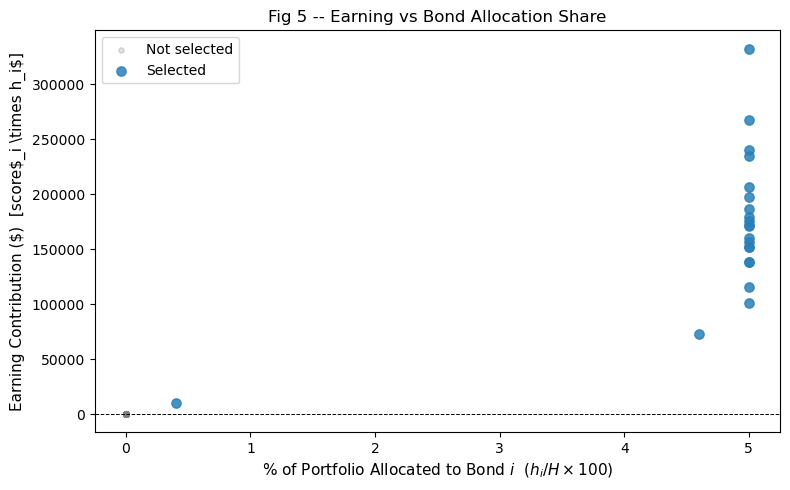

In [10]:
# =============================================================================
# 4E-1. FIG 5 -- Earning Contribution vs Bond Allocation Share
# =============================================================================
# Each point is one bond.
# X : share of total portfolio budget allocated to bond i  (h_i / H * 100, in %)
# Y : earnings contribution of bond i  (score_i * h_i, in $)
# Selected bonds (h > $1) are highlighted in blue.

pct_alloc     = h_opt / H * 100          # portfolio weight of each bond (%)
earn_per_bond = score * h_opt            # earning contribution per bond ($)
sel           = h_opt > 1.0             # bonds with non-trivial allocation

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(pct_alloc[~sel], earn_per_bond[~sel],
           alpha=0.25, color="grey", s=15, label="Not selected")
ax.scatter(pct_alloc[sel],  earn_per_bond[sel],
           alpha=0.85, color="#2980b9", s=45, label="Selected")
ax.axhline(0, color="black", linewidth=0.7, linestyle="--")
ax.set_xlabel("% of Portfolio Allocated to Bond $i$  ($h_i / H \\times 100$)", fontsize=11)
ax.set_ylabel("Earning Contribution ($)  [score$_i \\times h_i$]",              fontsize=11)
ax.set_title("Fig 5 -- Earning vs Bond Allocation Share", fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# 4E-2. FIGS 7-8 -- Optimal NEV vs Each Constraint Bound (Separate Figures)
# =============================================================================

def _solve_nev(H_=H, rbc_bar_=RBC_bar, eps_D_=eps_D, r_save_=None, r_borrow_=None):
    if r_save_   is None: r_save_   = r_save
    if r_borrow_ is None: r_borrow_ = r_borrow

    m2 = gp.Model("sens"); m2.Params.LogToConsole = 0; m2.Params.OutputFlag = 0

    h2  = m2.addVars(N, lb=0.0)
    for i in range(N):
        if post_fabn_mask[i]: h2[i].ub = 0.0
    dp2 = m2.addVar(lb=0.0);  dn2 = m2.addVar(lb=0.0)
    tp2 = m2.addVars(N, lb=0.0); tm2 = m2.addVars(N, lb=0.0)
    B2  = m2.addVars(Q, lb=0.0); sn2 = m2.addVars(Q, lb=0.0)

    si2 = gp.quicksum(score[i] * durs[i] * h2[i]  for i in range(N))  # duration-weighted spread income
    c1_ = gp.quicksum(theta[i] * h2[i]           for i in range(N))
    c3_ = alpha_w * (dp2 + dn2)
    tx_ = gp.quicksum(tau[i] * (tp2[i] + tm2[i]) for i in range(N))
    sav2 = r_save_   * dt_q * gp.quicksum(B2[q]  for q in range(Q - 1))
    bor2 = r_borrow_ * dt_q * gp.quicksum(sn2[q] for q in range(Q))
    m2.setObjective(si2 - gamma_w * rbc_bar_ * c1_ * D_FABN - tx_ + sav2 - bor2, GRB.MAXIMIZE)

    m2.addConstr(gp.quicksum(h2[i] for i in range(N)) == H_)
    m2.addConstr(gp.quicksum(durs[i] * h2[i] for i in range(N)) - D_FABN * H_
                 == dp2 - dn2)
    m2.addConstr(dp2 <= eps_D_ * H_); m2.addConstr(dn2 <= eps_D_ * H_)
    for i in range(N):
        m2.addConstr(h2[i] - h_curr[i] == tp2[i] - tm2[i])
    for iss, bidx in issuer_groups.items():
        m2.addConstr(gp.quicksum(h2[i] for i in bidx) <= delta * H_)
    for q in range(Q):
        cfa = gp.quicksum(qtr_bond_cf[q, i] * h2[i] for i in range(N))
        cfl = float(qtr_fabn_cf[q])
        if q == 0: m2.addConstr(B2[q] - sn2[q] == cfa - cfl)
        else:      m2.addConstr(B2[q] - sn2[q] == (1.0 + r_save_ * dt_q) * B2[q-1] + cfa - cfl)
    pv_l = float(sum(float(qtr_fabn_cf[q]) * df_q[q] for q in range(Q)))
    m2.addConstr(gp.quicksum(df_q[q] * sn2[q] for q in range(Q)) <= phi_sf * pv_l)

    m2.optimize()
    if m2.Status != GRB.OPTIMAL:
        return float("nan")
    return m2.ObjVal

import warnings; warnings.filterwarnings("ignore")

rbc_range = np.arange(0.0, 4.25, 0.25)   # 0 to 4 inclusive, step 0.25
eps_range = np.linspace(0.05, 1.5, 20)

print("Sweeping constraints -- 2x LP sweeps ...")
nev_rbc = [_solve_nev(rbc_bar_=v) for v in rbc_range]
nev_eps = [_solve_nev(eps_D_=v)   for v in eps_range]
print("Done.")

_kw  = dict(marker="o", markersize=4, linewidth=1.8)
_kvl = dict(color="red", linewidth=1.0, linestyle="--")

# --- Fig 7: RBC Capital Cost Sensitivity ---
fig7, ax7 = plt.subplots(figsize=(6, 5))
ax7.plot(rbc_range, nev_rbc, color="#3498db", **_kw)
ax7.axvline(RBC_bar, **_kvl, label=f"Current RBC_bar = {RBC_bar}")
ax7.set_xlabel("Min RBC Ratio  (RBC_ratio)")
ax7.set_ylabel("Optimal NEV ($)")
ax7.set_title("Fig 7 -- RBC Capital Cost Sensitivity (RBC_bar)")
ax7.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.2f}M"))
ax7.legend(fontsize=8)
plt.tight_layout()
plt.show()

# --- Fig 8: Duration Alignment ---
fig8, ax8 = plt.subplots(figsize=(6, 5))
ax8.plot(eps_range, nev_eps, color="#9b59b6", **_kw)
ax8.axvline(eps_D, **_kvl, label=f"Current eps_D = {eps_D}")
ax8.set_xlabel("Duration Tolerance  eps_D  (yrs)")
ax8.set_ylabel("Optimal NEV ($)")
ax8.set_title("Fig 8 -- Constraint 3: Duration Alignment")
ax8.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.2f}M"))
ax8.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# Note: Fig 9 is reserved; figure numbering continues at 10 for issuer concentration analysis
# =============================================================================
# 4E-3. FIGS 10-11 -- Issuer Concentration Constraint
# =============================================================================

# -- Fig 10: Current issuer allocations ----------------------------------------
issuer_alloc = {}
for idx, cusip in enumerate(CUSIPS):
    issuer_alloc.setdefault(cusip[:6], 0.0)
    issuer_alloc[cusip[:6]] += h_opt[idx]

issuer_s = pd.Series(issuer_alloc).sort_values(ascending=False)
issuer_s = issuer_s[issuer_s > 1.0]

cap_line = delta * H
pct_s    = issuer_s / H * 100
cap_pct  = delta * 100

colors_10 = ["#e67e22" if v >= cap_line * 0.999 else "#3498db" for v in issuer_s.values]

fig, ax = plt.subplots(figsize=(max(10, len(issuer_s) * 0.38), 5))
ax.bar(range(len(issuer_s)), pct_s.values, color=colors_10, edgecolor="white", linewidth=0.4)
ax.axhline(cap_pct, color="red", linewidth=1.3, linestyle="--",
           label=f"Cap  delta = {cap_pct:.0f}%  (${cap_line/1e6:.1f}M per issuer)")
ax.set_xticks(range(len(issuer_s)))
ax.set_xticklabels(pct_s.index, rotation=90, fontsize=7)
ax.set_xlabel("Issuer  (first 6 CUSIP chars)", fontsize=10)
ax.set_ylabel("% of Total Budget  H", fontsize=10)
ax.set_title("Fig 10 -- Issuer Concentration: Optimal Allocation vs Cap\n"
             "(orange = binding; blue = room below cap)", fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# -- Fig 11: NEV sensitivity to the per-issuer concentration cap ---------------
delta_range = np.linspace(0.005, 0.20, 20)

def _solve_nev_delta(delta_):
    """Solve a sub-model with a different issuer concentration cap and return the NEV."""
    m3 = gp.Model("sens_delta"); m3.Params.LogToConsole = 0; m3.Params.OutputFlag = 0

    h3  = m3.addVars(N, lb=0.0)
    for i in range(N):
        if post_fabn_mask[i]: h3[i].ub = 0.0
    dp3 = m3.addVar(lb=0.0);  dn3 = m3.addVar(lb=0.0)
    tp3 = m3.addVars(N, lb=0.0); tm3 = m3.addVars(N, lb=0.0)
    B3  = m3.addVars(Q, lb=0.0); sn3 = m3.addVars(Q, lb=0.0)

    si3 = gp.quicksum(score[i] * durs[i] * h3[i]  for i in range(N))  # duration-weighted spread income
    c1_ = gp.quicksum(theta[i] * h3[i]           for i in range(N))
    c3_ = alpha_w * (dp3 + dn3)
    tx_ = gp.quicksum(tau[i] * (tp3[i] + tm3[i]) for i in range(N))
    sav3 = r_save   * dt_q * gp.quicksum(B3[q]  for q in range(Q - 1))
    bor3 = r_borrow * dt_q * gp.quicksum(sn3[q] for q in range(Q))
    m3.setObjective(si3 - gamma_w * RBC_bar * c1_ * D_FABN - tx_ + sav3 - bor3, GRB.MAXIMIZE)

    m3.addConstr(gp.quicksum(h3[i] for i in range(N)) == H)
    m3.addConstr(gp.quicksum(durs[i] * h3[i] for i in range(N)) - D_FABN * H == dp3 - dn3)
    m3.addConstr(dp3 <= eps_D * H); m3.addConstr(dn3 <= eps_D * H)
    for i in range(N):
        m3.addConstr(h3[i] - h_curr[i] == tp3[i] - tm3[i])
    for iss, bidx in issuer_groups.items():
        m3.addConstr(gp.quicksum(h3[i] for i in bidx) <= delta_ * H)
    for q in range(Q):
        cfa = gp.quicksum(qtr_bond_cf[q, i] * h3[i] for i in range(N))
        cfl = float(qtr_fabn_cf[q])
        if q == 0: m3.addConstr(B3[q] - sn3[q] == cfa - cfl)
        else:      m3.addConstr(B3[q] - sn3[q] == (1.0 + r_save * dt_q) * B3[q-1] + cfa - cfl)
    pv_l = float(sum(float(qtr_fabn_cf[q]) * df_q[q] for q in range(Q)))
    m3.addConstr(gp.quicksum(df_q[q] * sn3[q] for q in range(Q)) <= phi_sf * pv_l)

    m3.optimize()
    if m3.Status != GRB.OPTIMAL:
        return float("nan")
    return m3.ObjVal

print("Sweeping issuer concentration cap -- 20 LP solves ...")
nev_delta = [_solve_nev_delta(d) for d in delta_range]
print("Done.")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(delta_range * 100, nev_delta, "o-", color="#e74c3c", linewidth=1.8, markersize=4)
ax.axvline(delta * 100, color="red", linewidth=1.0, linestyle="--",
           label=f"Current delta = {delta:.0%}")
ax.set_xlabel("Max Issuer Allocation  delta  (% of H)", fontsize=11)
ax.set_ylabel("Optimal NEV ($)", fontsize=11)
ax.set_title("Fig 11 -- Constraint 2E: NEV vs Issuer Concentration Cap (delta)", fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.2f}M"))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Sweeping r_save and r_borrow -- 2x20 LP solves ...
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0
Set parameter LogToConsole to value 0

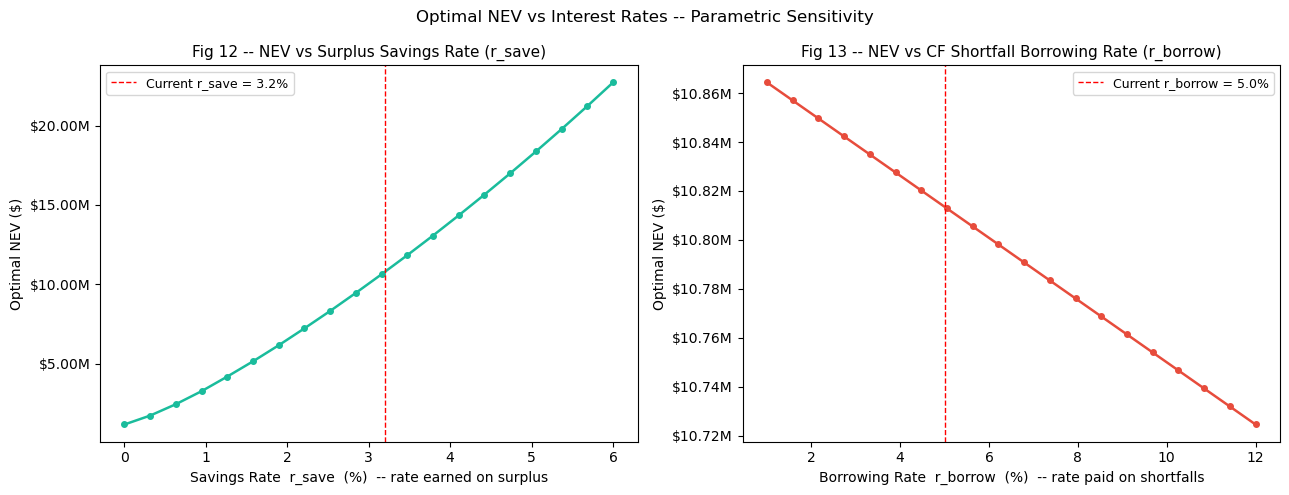

In [13]:
# =============================================================================
# 4E-4. FIGS 12-13 -- NEV Sensitivity to Savings Rate (r_save) and Borrowing Rate (r_borrow)
# =============================================================================
# Sweeps each interest rate independently; all other parameters held at Section 2 values.
# Red dashed line marks the value used in the main run.

r_save_range   = np.linspace(0.00, 0.06, 20)   # 0% to 6%
r_borrow_range = np.linspace(0.01, 0.12, 20)   # 1% to 12%

print("Sweeping r_save and r_borrow -- 2x20 LP solves ...")
nev_rsave   = [_solve_nev(r_save_=v)   for v in r_save_range]
nev_rborrow = [_solve_nev(r_borrow_=v) for v in r_borrow_range]
print("Done.")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Optimal NEV vs Interest Rates -- Parametric Sensitivity", fontsize=12)

_kw  = dict(marker="o", markersize=4, linewidth=1.8)
_kvl = dict(color="red", linewidth=1.0, linestyle="--")

ax = axes[0]
ax.plot(r_save_range * 100, nev_rsave, color="#1abc9c", **_kw)
ax.axvline(r_save * 100, **_kvl, label=f"Current r_save = {r_save*100:.1f}%")
ax.set_xlabel("Savings Rate  r_save  (%)  -- rate earned on surplus", fontsize=10)
ax.set_ylabel("Optimal NEV ($)")
ax.set_title("Fig 12 -- NEV vs Surplus Savings Rate (r_save)", fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.2f}M"))
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(r_borrow_range * 100, nev_rborrow, color="#e74c3c", **_kw)
ax.axvline(r_borrow * 100, **_kvl, label=f"Current r_borrow = {r_borrow*100:.1f}%")
ax.set_xlabel("Borrowing Rate  r_borrow  (%)  -- rate paid on shortfalls", fontsize=10)
ax.set_ylabel("Optimal NEV ($)")
ax.set_title("Fig 13 -- NEV vs CF Shortfall Borrowing Rate (r_borrow)", fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.2f}M"))
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()